## Evaluating Returns of Historical Stock Data
This notebook shows a basic analysis of the daily data for the S&P 500 index to demonstrate some of the fundamental statistical properties of the returns. The data will be imported from Yahoo Finance using the yfinance package with the ^GSPC ticker over the 1/1/2020-7/1/2026 date range. 

In [346]:
import numpy as np
from scipy.stats import skew, kurtosis, probplot, norm, skewtest, kurtosistest
from scipy.signal import correlate
import pandas as pd
import yfinance as yf
import datetime as dt
import matplotlib.pyplot as plt

In [213]:
start_date = dt.datetime(2020,1,1)
end_date = dt.datetime(2026,7,1)

index_data = yf.download(['^GSPC'], start=start_date, end=end_date)

[*********************100%***********************]  1 of 1 completed


The most basic way to review the index data is to look at its value over time. The data from yfinance returns the open value, close value, high value, low value, and volume. This analysis will only look at the closing value since it is intended to track the value over time. 

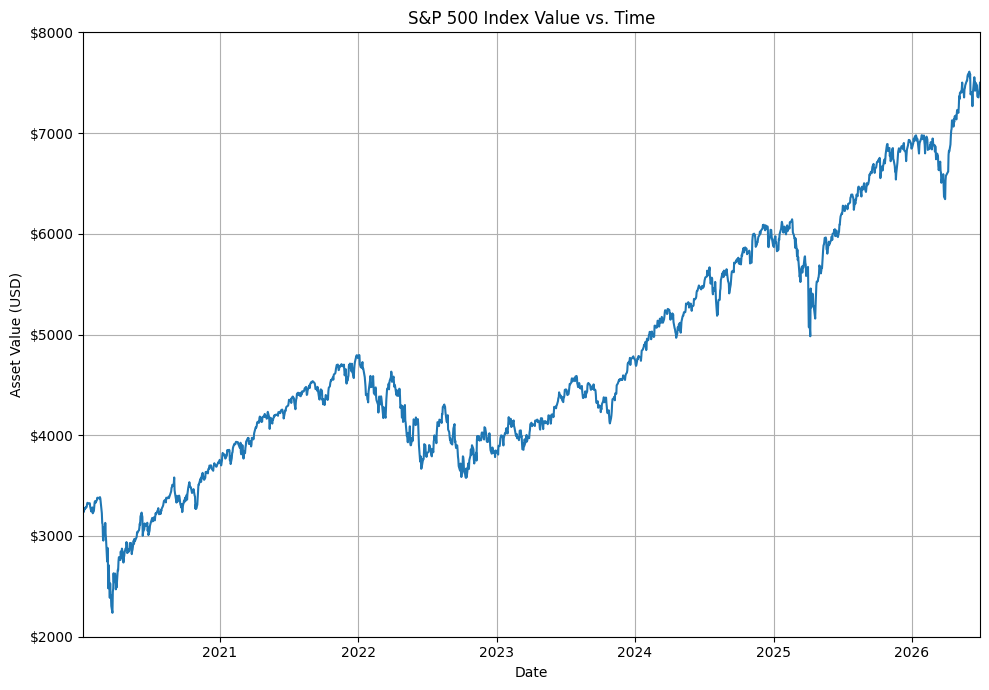

In [214]:
fig, ax = plt.subplots(figsize=(10,7))
ax.plot(index_data.index, index_data['Close'])
ax.set_xlim(left=index_data.index[2], right=index_data.index[-1])
ax.set_ylim(bottom=2000, top=8000); ax.grid(); ax.set_xlabel('Date'); 
ax.set_ylabel('Asset Value (USD)'); ax.yaxis.set_major_formatter('${x:1.0f}')
ax.set_title('S&P 500 Index Value vs. Time'); fig.tight_layout()

## Simple Rate of Returns
While it is interesting to review the value of an asset over time, a more useful analysis (for modeling the value) might be to track how the value changes over time, also known as the returns of an asset. The basic equation for computing the value of an asset over time is:

$$
S(t) = S(t-1) + S(t-1)R(t) = S(t-1) \begin{pmatrix}1 + R(t)\end{pmatrix}
$$

where $S(t)$ is the asset value at time $t$, $R(t)$ is the "simple" rate of returns, and $\begin{pmatrix}1 + R(t)\end{pmatrix}$ is the simple gross returns. 

```{note}
The gross returns and rate of returns describe the same exact concept. The only difference is that gross return describes the total value of the asset whereas the rate of returns only describes the value of the return. I.E., the gross returns for an asset that has changed from $100 to $150 would be 150% while the rate of returns is 50%.
```

The above equation can be re-arranged to compute the simple rate of returns, which is simply the percent change in the value of the asset:

$$
R(t) = \frac{S(t)}{S(t-1)} - 1 = \frac{S(t)-S(t-1)}{S(t-1)}
$$ 

### Compounding Returns
The simple returns on an asset value compound over time, since the percentage change at the present sample includes all the previous percentage changes. A simple example can be used to demonstrate how the returns compound over time. First, the asset value is computed for $t-1$:

$$
S(t-1) = S(t-2) \begin{pmatrix}1 + R(t-1)\end{pmatrix}
$$

this equation is then inserted into the first equation above to compute the asset value at time $t$, starting at time $t-2$:

$$
S(t) =  S(t-2) \begin{pmatrix}1 + R(t-1)\end{pmatrix} \begin{pmatrix}1 + R(t)\end{pmatrix}
$$

consequently, the gross rate of returns from $t_0$ to $t_n$ is the multiplication of the simple gross returns for all the previous periods (days, months, years, etc.).

### Computing Returns
The index data from yfinance is returned as a Pandas DataFrame, which makes it simple to compute the simple returns using the `pct_change` method. The percentage change is undefined for the first day, which is why the simple returns are indexed starting from the second value. 

In [ ]:
index_simple_returns = index_data['Close'].pct_change().to_numpy()[1:,0]
index_gross_returns = 1 + index_simple_returns

The simple returns vs. time are shown in the plot below. This plot shows how the returns appear random and that the mean value is slightly greater than zero. 

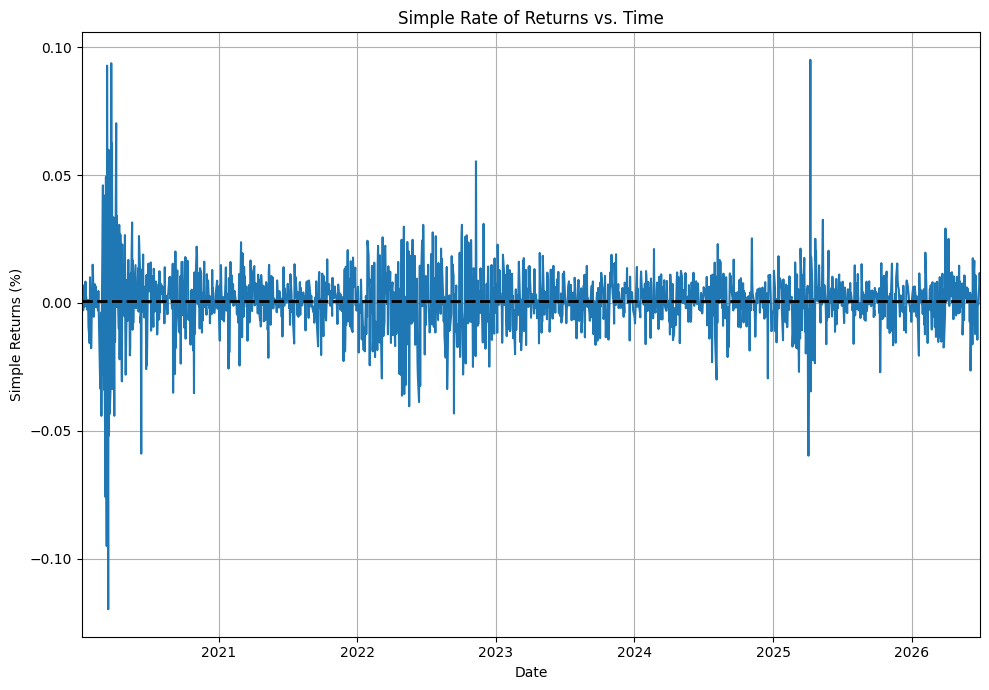

In [332]:
plt.figure(figsize=(10,7))
plt.plot(index_data.index[1:], index_simple_returns)
plt.axhline(index_simple_returns.mean(), color='k', linestyle='--', linewidth=2)
plt.xlim(left=index_data.index[2], right=index_data.index[-1])
plt.grid(); plt.xlabel('Date'); plt.ylabel('Simple Returns (%)')
plt.title('Simple Rate of Returns vs. Time'); plt.tight_layout()

The distribution of the returns can also be reviewed to see how they compare to the normal distribution. This is shown below in three ways. First, a histogram of the returns (after scaling so the area under the curve sums to one) is compared to the probability density function (PDF) that is created from the mean and standard deviation of the returns. This is shown in the plot below where it can be seen that the histogram does not match the theoretical PDF. There are two discrepancies in this plot:

- The are many more samples near the mean than in the theoretical PDF
- There are some signs of heavy tails although it is very obvious

In [217]:
index_simple_return_pdf_abscissa = np.linspace(index_simple_returns.min(), index_simple_returns.max(), 100)
index_simple_return_pdf_ordinate = norm.pdf(index_simple_return_pdf_abscissa, loc=np.mean(index_simple_returns), 
                                            scale=np.std(index_simple_returns))

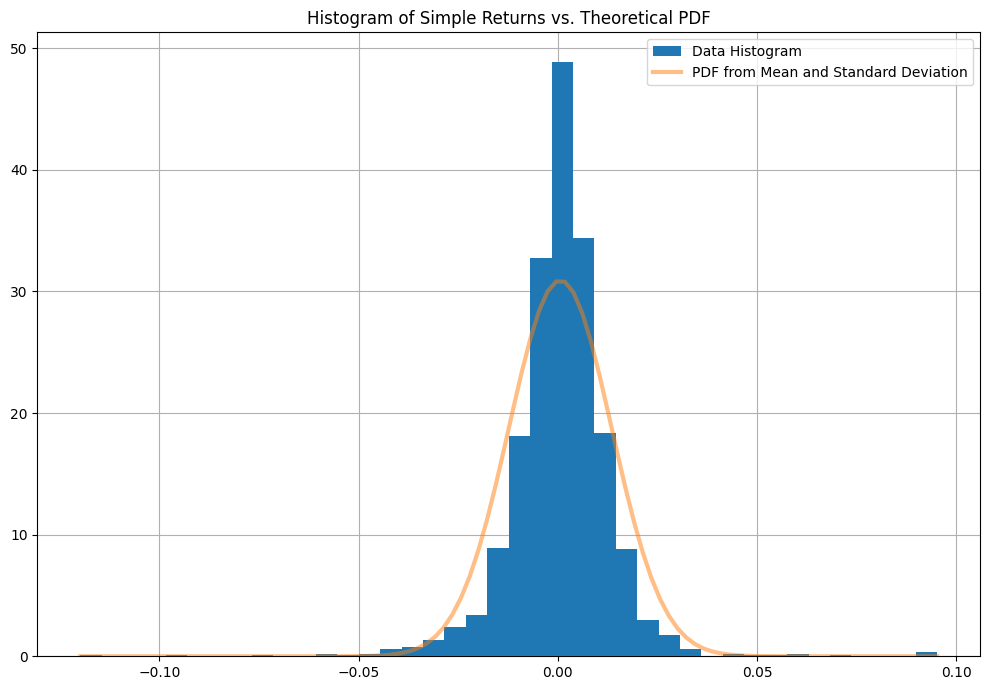

In [335]:
plt.figure(figsize=(10,7))
plt.hist(index_simple_returns, bins=40, label='Data Histogram', zorder=3, density=True);
plt.plot(index_simple_return_pdf_abscissa, index_simple_return_pdf_ordinate, linewidth=3, 
         label='PDF from Mean and Standard Deviation', zorder=4, alpha=0.5)
plt.legend(); plt.grid(zorder=0); plt.title('Histogram of Simple Returns vs. Theoretical PDF');
plt.tight_layout()

Secondly, the statistical moments of the returns can be reviewed, as shown below. 

In [219]:
print('Average simple return: {:}'.format(np.mean(index_simple_returns)))
print('Simple return standard deviation {:}'.format(np.std(index_simple_returns)))
print('Simple return variance: {:}'.format(np.var(index_simple_returns)))
print('Simple return skewness: {:}'.format(skew(index_simple_returns)))
print('Simple return excess kurtosis: {:}'.format(kurtosis(index_simple_returns, fisher=True)))

Average simple return: 0.0005952137211318747
Simple return standard deviation 0.012905685166878001
Simple return variance: 0.00016655670962657486
Simple return skewness: -0.3274095892756203
Simple return excess kurtosis: 13.990972441017313


The skewness and kurtosis should be compared to a critical value using a t-ratio statistic that is computed with:

$$
t_{skew} = \frac{\hat{S}}{SE_{skew}}
$$
$$
t_{kurt} = \frac{\hat{K}}{SE_{kurt}}
$$

where $\hat{S}$ is the skewness of the returns, $\hat{K}$ is the kurtosis of the returns, $SE_{skew}$ is the standard error of the skewness, and $SE_{kurt}$ is the standard error of the kurtosis. The standard errors are computed with:

$$
SE_{skew}=\sqrt{\frac{6}{n}}
$$
$$
SE_{kurt}=\sqrt{\frac{24}{n}}
$$

where $n$ is the number of samples in the returns. The t-ratio statistic is compared to a z-value to determine if the skewness or kurtosis is significantly different from the normal distribution, where the z-value is the quantile of the standard normal distribution that is less than. Alternatively, the absolute value of the skewness or kurtosis can be compared to the "critical" skewness or kurtosis, which is computed with:

$$
\hat{S}_{critical} = z*SE_{skew}
$$
$$
\hat{K}_{critical} = z*SE_{kurt}
$$

The critical skewness and kurtosis values are shown below for a 5% significance level. Both the sample skewness and kurtosis are greater than the critical values, which means that the data is likely not from a normal distribution. 

In [341]:
print('Critical skewness value: {:}'.format(norm.ppf(1-0.05/2)*np.sqrt(6/index_simple_returns.shape[0])))
print('Critical kurtosis value: {:}'.format(norm.ppf(1-0.05/2)*np.sqrt(24/index_simple_returns.shape[0])))

Critical skewness value: 0.11891315830167404
Critical kurtosis value: 0.23782631660334808


Alternatively, the p-values from the SciPy `skewtest` and `kurtosistest` functions can be used to evaluate the same thing as the critical skewness or kurtosis. The p-values in these [tests](https://docs.scipy.org/doc/scipy/tutorial/stats/hypothesis_skewtest.html#hypothesis-skewtest) are the proportion of values in the standard normal distribution that are as extreme or more extreme than the statistic from the test. As such, the skewness or kurtosis is significantly different from the normal distribution if the p-value is small, which is the case for both the skewness and kurtosis of the simple returns. 

In [347]:
skewtest(index_simple_returns).pvalue

np.float64(1.2428082879189802e-07)

In [348]:
kurtosistest(index_simple_returns).pvalue

np.float64(1.221550282404566e-78)

Lastly, the returns can be reviewed with a probability plot, which plots the sorted values against the theoretical quantiles. In this case the sorted values should fall on a straight line (the red line in the plot below) if the data is sampled from a normal distribution. As expected, this plot shows that the distribution of returns has heavy tails since the actual values at the higher theoretical quantiles are much higher than theoretical values. Further, the actual values in the middle of the curve are flatter than the theoretical curve, which indicates that the returns are generally closer to the mean than what would be expected from a normal distribution. 

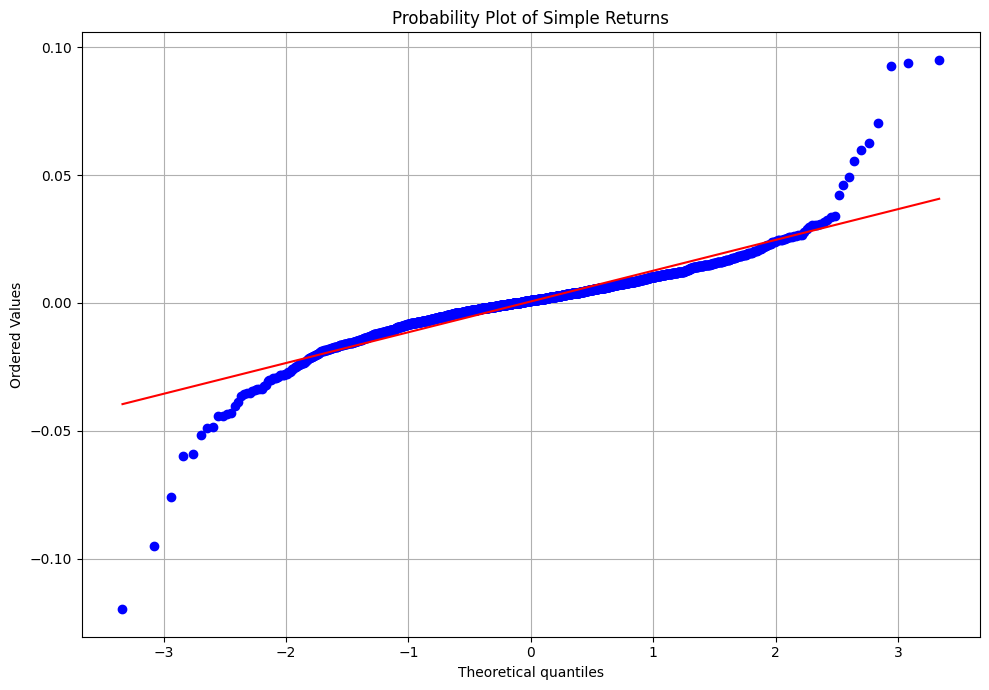

In [220]:
fig, ax = plt.subplots(figsize=(10,7))
res = probplot(index_simple_returns, plot=ax)
ax.set_title('Probability Plot of Simple Returns'); ax.grid()
fig.tight_layout()

## Log Returns
Given the compounding of the returns, the asset value can also be computed with the exponential function instead of the series of multiplications that was shown above:

$$
S(t) = S(t-1) e^{r(t)}
$$

where $r(t)$ is the "log-returns" that are computed with the natural log of gross returns:

$$
r(t) = ln\begin{pmatrix}1+R(t)\end{pmatrix}
$$

Using the exponential function and log-returns to model the asset value has two significant benefits:

1. The returns from the exponential function are continuous in time
2. The log-returns are additive in time rather than multiplicative, since the compounded log-return is:

$$
ln\begin{pmatrix}\begin{pmatrix}1 + R(t)\end{pmatrix} \begin{pmatrix}1 + R(t-1)\end{pmatrix} + ...\end{pmatrix} = ln\begin{pmatrix}1 + R(t)\end{pmatrix} + ln\begin{pmatrix}1 + R(t-1)\end{pmatrix} + ... = r(t) + r(t-1) + ...
$$

These benefits make the log-returns the preferred value for modeling time series. Interestingly, the log-returns are not significantly different than the simple returns for the daily values since the daily returns have very small amplitudes. This similarity is shown in the plot below which shows both the log returns and simple returns. They only differences are noticeable at the high amplitude samples where there are subtle differences. 

In [221]:
index_log_returns = np.log(index_gross_returns)

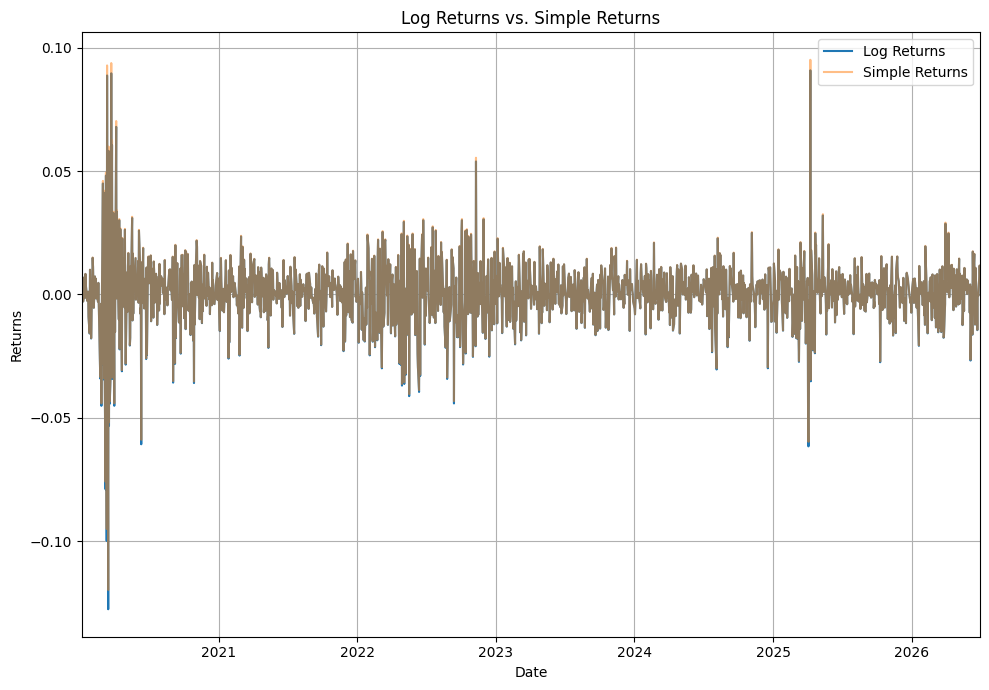

In [349]:
plt.figure(figsize=(10,7))
plt.plot(index_data.index[1:], index_log_returns, label='Log Returns')
plt.plot(index_data.index[1:], index_simple_returns, alpha=0.5, label='Simple Returns')
plt.xlim(left=index_data.index[2], right=index_data.index[-1]); plt.legend()
plt.grid(); plt.xlabel('Date'); plt.ylabel('Returns')
plt.title('Log Returns vs. Simple Returns'); plt.tight_layout()

## Time Varying Nature of Returns
Modeling the returns with a single distribution may be error prone since many assets have time varying properties (given the underlying market dynamics). The classical time varying property in returns is "volatility clustering". This can be seen in the plot below where the blue curve is the log-returns and the orange curve is the twenty day rolling standard deviation. The rolling standard deviation tends to be at the same level for most of the time. However, there are several times (with significant durations) where the standard deviation has a significantly higher amplitude.

In [268]:
rolling_std = pd.DataFrame(index_log_returns).rolling(20).std().to_numpy()[19:,0]

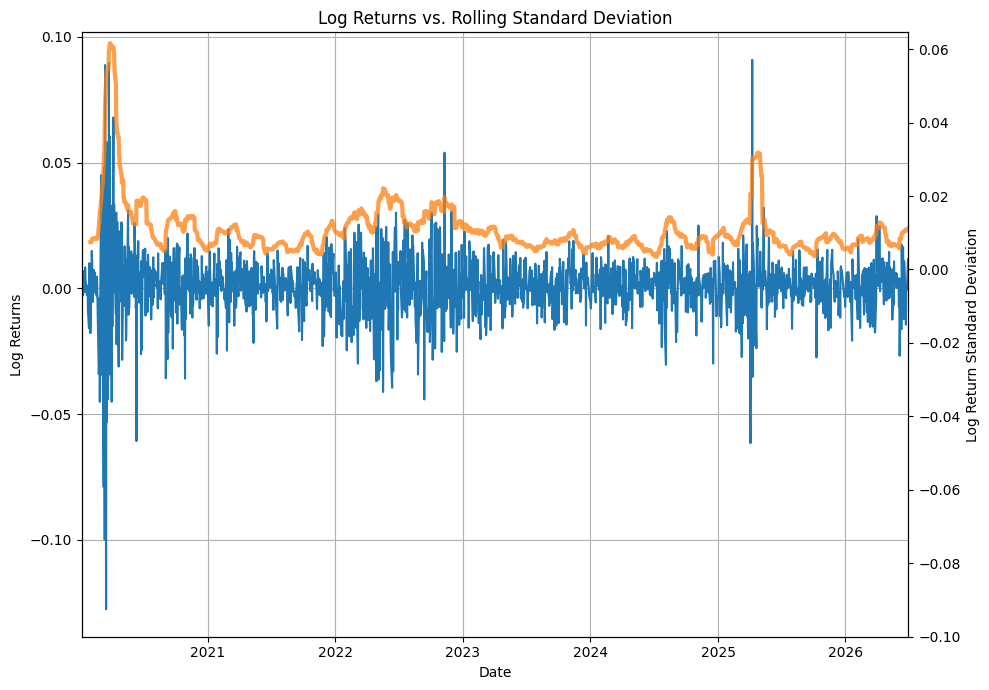

In [ ]:
fig, ax = plt.subplots(figsize=(10,7))
ax.plot(index_data.index[1:], index_log_returns)
ax.set_xlim(left=index_data.index[2], right=index_data.index[-1])
ax2 = ax.twinx()
ax2.plot(index_data.index[20:], rolling_std, color='tab:orange',
         linewidth=3, alpha=0.75)
ax2.set_ylim(bottom=-0.1)
ax.grid(); ax.set_xlabel('Date'); ax.set_ylabel('Log Returns')
ax2.set_ylabel('Log Return Standard Deviation'); 
ax.set_title('Log Returns vs. Rolling Standard Deviation')
fig.tight_layout()

The time varying nature of the returns can also be seen in the twenty day rolling kurtosis, as shown in the plot below. The rolling kurtosis changes less frequently than the rolling standard deviation, but shows a similar behavior where the excess kurtosis is near zero for most of the time, but can be much higher for brief periods of time. 

In [274]:
rolling_kurtosis = pd.DataFrame(index_log_returns).rolling(20).kurt().to_numpy()[19:,0]

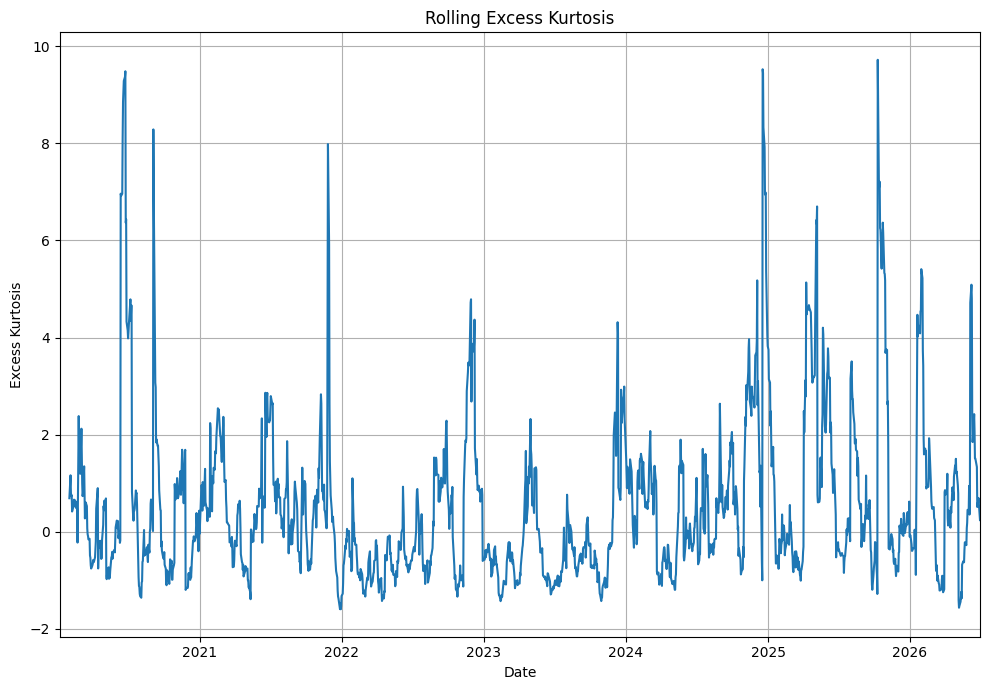

In [276]:
plt.figure(figsize=(10,7))
plt.plot(index_data.index[20:], rolling_kurtosis)
plt.xlim(left=index_data.index[2], right=index_data.index[-1])
plt.grid(); plt.xlabel('Date'); plt.ylabel('Excess Kurtosis')
plt.title('Rolling Excess Kurtosis'); plt.tight_layout()

Lastly, the autocorrelation of the log-returns show how the returns are time varying in nature, since the autocorrelation only has a high amplitude for one or two lags. 

In [353]:
auto_correlation = correlate(index_log_returns-index_log_returns.mean(), 
                             index_log_returns-index_log_returns.mean())
auto_correlation /= auto_correlation[index_log_returns.shape[0]-1]

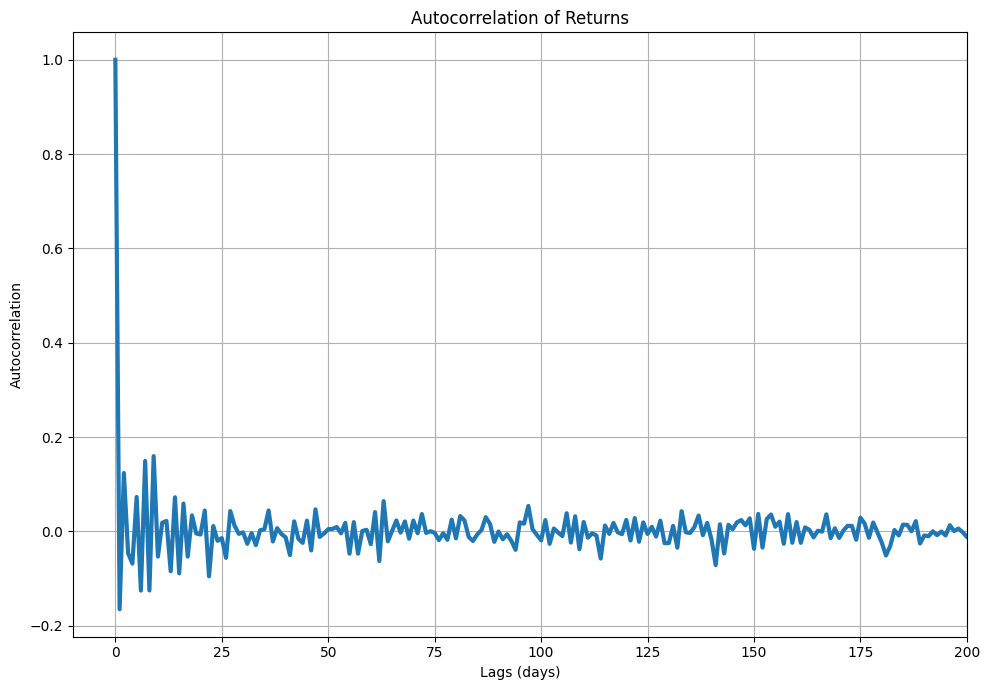

In [355]:
plt.figure(figsize=(10,7))
plt.plot(auto_correlation[index_log_returns.shape[0]-1:], linewidth=3)
plt.xlim(left=-10, right=200)#auto_correlation[index_log_returns.shape[0]-1:].shape[0]); 
plt.grid(); plt.xlabel('Lags (days)'); plt.ylabel('Autocorrelation')
plt.title('Autocorrelation of Returns'); plt.tight_layout()